In [ ]:
%pip install pandas matplotlib

In [3]:
%pip list | grep pandas

pandas                  3.0.1
Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install duckdb jupysql duckdb-engine

In [1]:
import pandas as pd
import os

In [2]:
%load_ext sql
%sql duckdb:///:memory:

Connecting to 'duckdb:///:memory:'

In [2]:
path_to_dataset = '../data/raw/data.csv'

if not os.path.isfile(path_to_dataset):
    print('fail')
else:
    df = pd.read_csv(path_to_dataset)

In [4]:
import duckdb

In [5]:
con = duckdb.connect(database=':memory:')

%sql con

In [6]:
%%sql

SELECT *
FROM
    df
ORDER BY
    RANDOM()
LIMIT 5;

Running query in 'DuckDBPyConnection'

Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
TXN_7260,USER_5311,74.8,POS,2023-12-02 21:23:00,76372.98,Tablet,London,Restaurants,0,1,12,239.24,1,Mastercard,22,1817.84,Password,0.0417,0,0
TXN_3942,USER_7139,21.18,Bank Transfer,2023-05-31 12:06:00,75710.98,Tablet,Tokyo,Groceries,0,1,2,386.96,3,Discover,155,2300.18,PIN,0.3743,1,0
TXN_4798,USER_8500,56.3,Online,2023-12-26 07:08:00,90380.07,Laptop,London,Travel,1,0,10,366.01,3,Amex,38,911.05,OTP,0.8239,1,0
TXN_42056,USER_2597,10.14,Bank Transfer,2023-03-17 10:13:00,24016.54,Laptop,Mumbai,Clothing,0,0,10,170.14,3,Amex,36,3165.15,PIN,0.1489,0,0
TXN_19914,USER_3193,198.62,POS,2023-01-22 20:32:00,42430.7,Laptop,Tokyo,Restaurants,0,0,9,197.45,4,Discover,154,3793.33,Biometric,0.7799,1,1


In [3]:
df.shape

(750, 16)

In [4]:
df.columns

Index(['quarter', 'stock', 'date', 'open', 'high', 'low', 'close', 'volume',
       'percent_change_price', 'percent_change_volume_over_last_wk',
       'previous_weeks_volume', 'next_weeks_open', 'next_weeks_close',
       'percent_change_next_weeks_price', 'days_to_next_dividend',
       'percent_return_next_dividend'],
      dtype='str')

In [5]:
df.describe()

,quarter,volume,percent_change_price,percent_change_volume_over_last_wk,previous_weeks_volume,percent_change_next_weeks_price,days_to_next_dividend,percent_return_next_dividend
count,750.000000,7.500000e+02,750.000000,720.000000,7.200000e+02,750.000000,750.000000,750.000000
mean,1.520000,1.175478e+08,0.050262,5.593627,1.173876e+08,0.238468,52.525333,0.691826
std,0.499933,1.584381e+08,2.517809,40.543478,1.592322e+08,2.679538,46.335098,0.305482
min,1.000000,9.718851e+06,-15.422900,-61.433175,9.718851e+06,-15.422900,0.000000,0.065574
25%,1.000000,3.086624e+07,-1.288053,-19.804284,3.067832e+07,-1.222068,24.000000,0.534549
50%,2.000000,5.306088e+07,0.000000,0.512586,5.294556e+07,0.101193,47.000000,0.681067
75%,2.000000,1.327218e+08,1.650888,21.800622,1.333230e+08,1.845562,69.000000,0.854291
max,2.000000,1.453439e+09,9.882230,327.408924,1.453439e+09,9.882230,336.000000,1.564210


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   quarter                             750 non-null    int64  
 1   stock                               750 non-null    str    
 2   date                                750 non-null    str    
 3   open                                750 non-null    str    
 4   high                                750 non-null    str    
 5   low                                 750 non-null    str    
 6   close                               750 non-null    str    
 7   volume                              750 non-null    int64  
 8   percent_change_price                750 non-null    float64
 9   percent_change_volume_over_last_wk  720 non-null    float64
 10  previous_weeks_volume               720 non-null    float64
 11  next_weeks_open                     750 non-null    str 

In [7]:
df.isna().sum()

quarter                                0
stock                                  0
date                                   0
open                                   0
high                                   0
low                                    0
close                                  0
volume                                 0
percent_change_price                   0
percent_change_volume_over_last_wk    30
previous_weeks_volume                 30
next_weeks_open                        0
next_weeks_close                       0
percent_change_next_weeks_price        0
days_to_next_dividend                  0
percent_return_next_dividend           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [13]:
%%sql

DESCRIBE df;

Running query in 'DuckDBPyConnection'

column_name,column_type,null,key,default,extra
Transaction_ID,VARCHAR,YES,None,None,None
User_ID,VARCHAR,YES,None,None,None
Transaction_Amount,DOUBLE,YES,None,None,None
Transaction_Type,VARCHAR,YES,None,None,None
Timestamp,VARCHAR,YES,None,None,None
Account_Balance,DOUBLE,YES,None,None,None
Device_Type,VARCHAR,YES,None,None,None
Location,VARCHAR,YES,None,None,None
Merchant_Category,VARCHAR,YES,None,None,None
IP_Address_Flag,BIGINT,YES,None,None,None


In [ ]:
%pip install seaborn

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Obs
 Fraud_Label
0    33933
1    16067
Name: count, dtype: int64

Procentaj:
 Fraud_Label
0    67.866
1    32.134
Name: proportion, dtype: float64


/tmp/ipykernel_6435/2333769528.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Fraud_Label', data=df, palette='viridis')


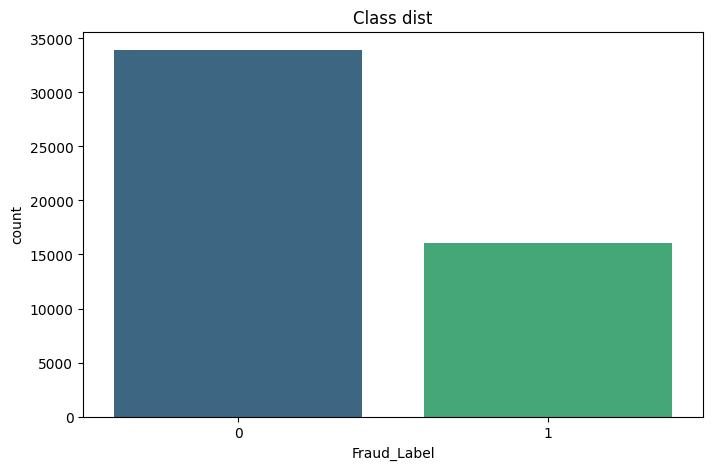

In [17]:
counts = df['Fraud_Label'].value_counts()
percentages = df['Fraud_Label'].value_counts(normalize=True) * 100

print("Obs\n", counts)
print("\nProcentaj:\n", percentages)

plt.figure(figsize=(8, 5))
sns.countplot(x='Fraud_Label', data=df, palette='viridis')
plt.title('Class dist')
plt.show()

In [18]:
import seaborn as sns
import numpy as np

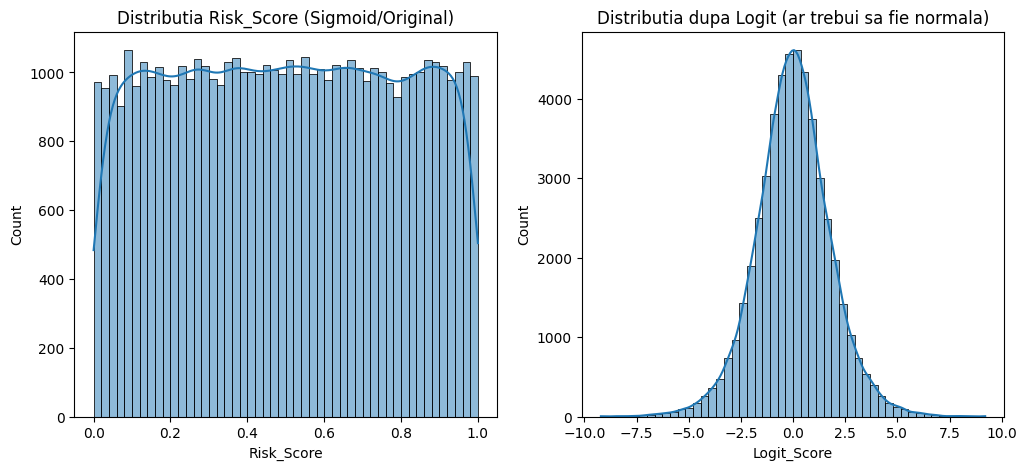

In [19]:
risk_clipped = df['Risk_Score'].clip(0.0001, 0.9999)

df['Logit_Score'] = np.log(risk_clipped / (1 - risk_clipped))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Risk_Score'], bins=50, kde=True)
plt.title('Distributia Risk_Score (Sigmoid/Original)')

plt.subplot(1, 2, 2)
sns.histplot(df['Logit_Score'], bins=50, kde=True)
plt.title('Distributia dupa Logit (ar trebui sa fie normala)')

plt.show()